In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
import joblib

In [31]:
df=pd.read_csv("Customer_Financial_Info.csv")

In [32]:
df.columns = df.columns.str.strip()

In [33]:
df.head(10)

,Customer_ID,Age,Years_Experience,Annual_Income,ZIP_Code,Family_size,Avg_Spending,Education_Level,Mortgage,Has_Consumer_Loan,Has_Securities_Account,Has_CD_Account,Uses_Online_Banking,Has_CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   int64  
 1   Age                     5000 non-null   int64  
 2   Years_Experience        5000 non-null   int64  
 3   Annual_Income           5000 non-null   int64  
 4   ZIP_Code                5000 non-null   int64  
 5   Family_size             5000 non-null   int64  
 6   Avg_Spending            5000 non-null   float64
 7   Education_Level         5000 non-null   int64  
 8   Mortgage                5000 non-null   int64  
 9   Has_Consumer_Loan       5000 non-null   int64  
 10  Has_Securities_Account  5000 non-null   int64  
 11  Has_CD_Account          5000 non-null   int64  
 12  Uses_Online_Banking     5000 non-null   int64  
 13  Has_CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 5

In [35]:
df.describe()

,Customer_ID,Age,Years_Experience,Annual_Income,ZIP_Code,Family_size,Avg_Spending,Education_Level,Mortgage,Has_Consumer_Loan,Has_Securities_Account,Has_CD_Account,Uses_Online_Banking,Has_CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [36]:
df.isnull().sum()

Customer_ID               0
Age                       0
Years_Experience          0
Annual_Income             0
ZIP_Code                  0
Family_size               0
Avg_Spending              0
Education_Level           0
Mortgage                  0
Has_Consumer_Loan         0
Has_Securities_Account    0
Has_CD_Account            0
Uses_Online_Banking       0
Has_CreditCard            0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df = df.drop(columns=["Customer_ID", "ZIP_Code"])

In [39]:
neg_cols = [col for col in df.select_dtypes(include='number').columns if (df[col] < 0).any()]
for col in neg_cols:
  median_exp = df.loc[df['Years_Experience'] >= 0, 'Years_Experience'].median()
  df.loc[df['Years_Experience'] < 0, 'Years_Experience'] = median_exp

In [40]:
cols_numeric = df.select_dtypes(include=['int64', 'float64']).columns

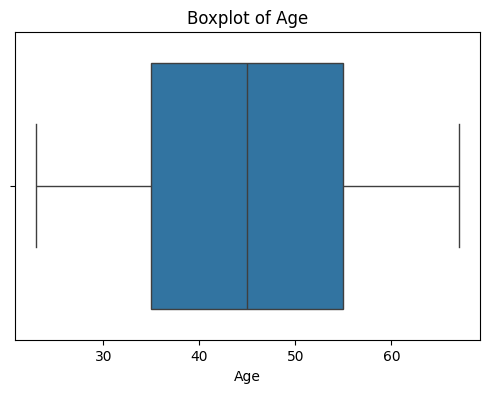

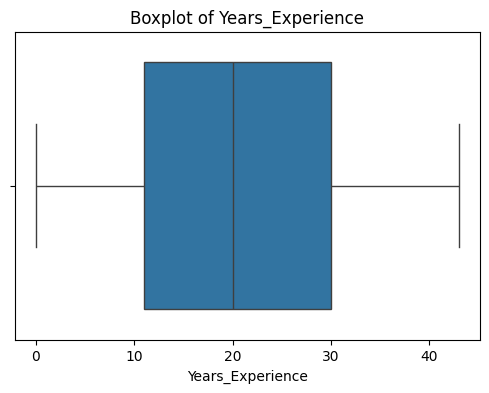

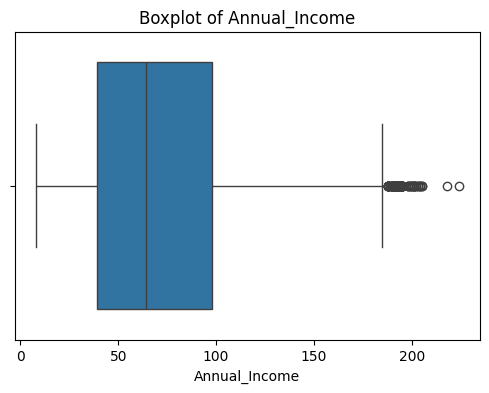

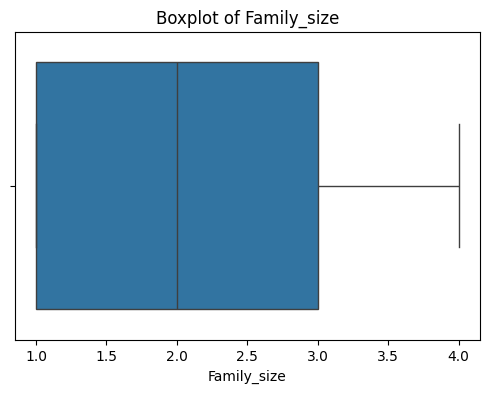

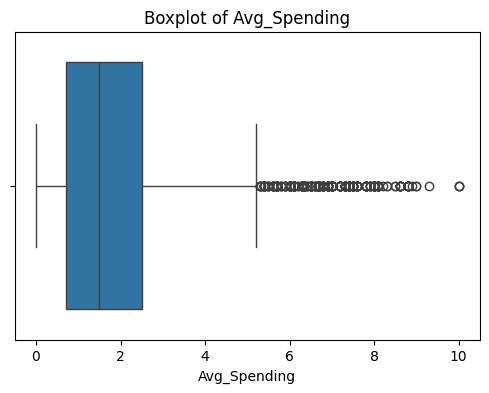

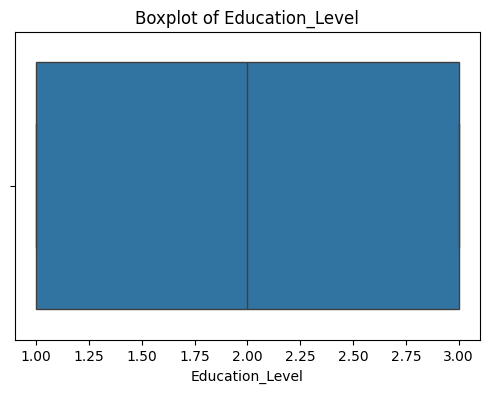

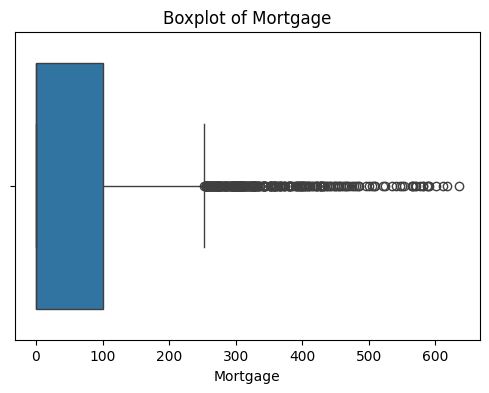

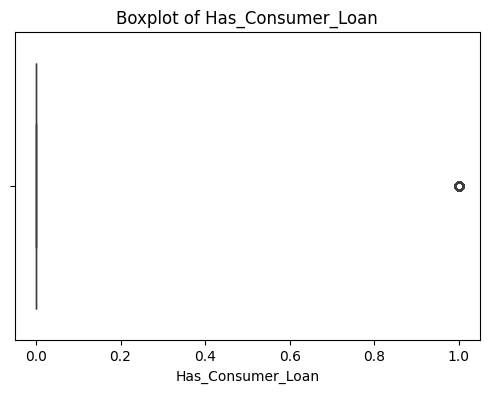

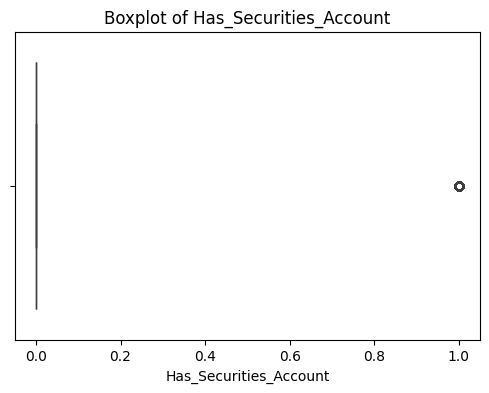

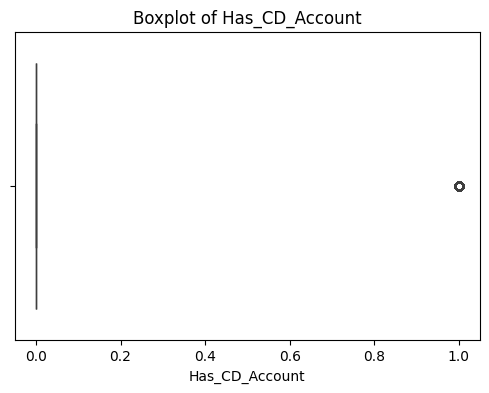

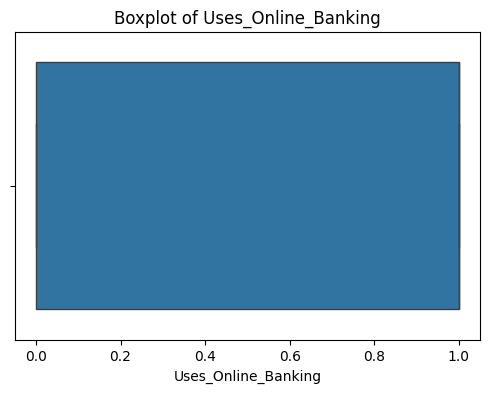

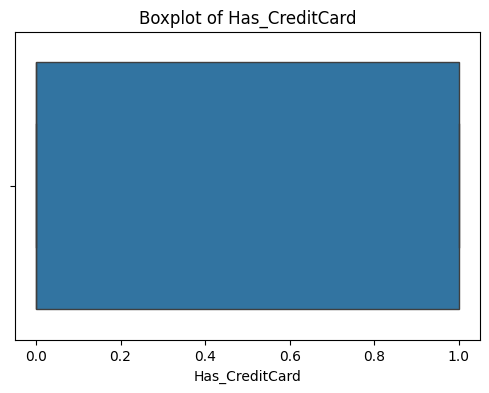

In [41]:
for col in cols_numeric:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

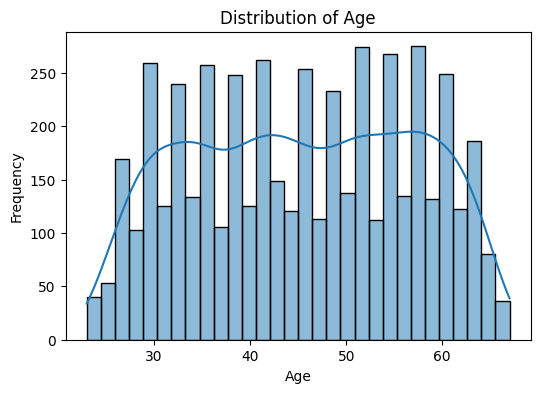

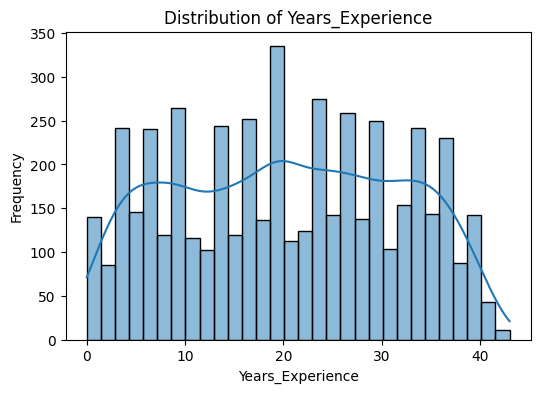

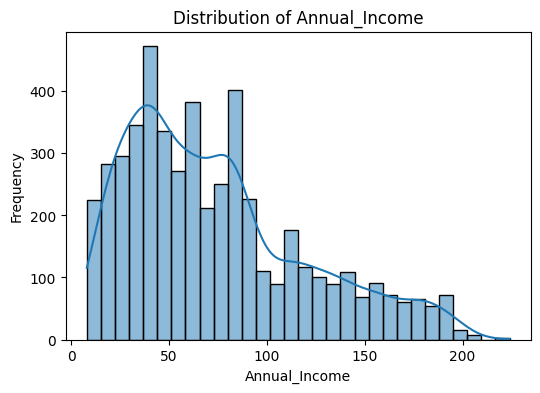

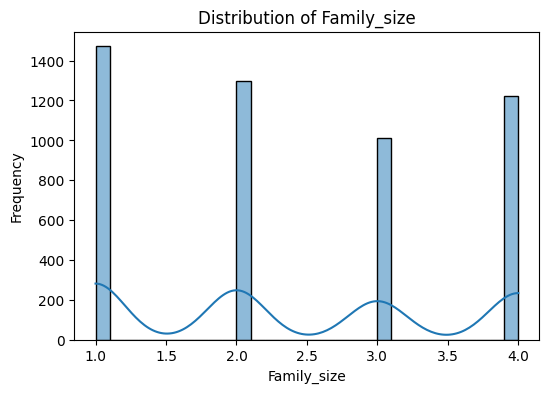

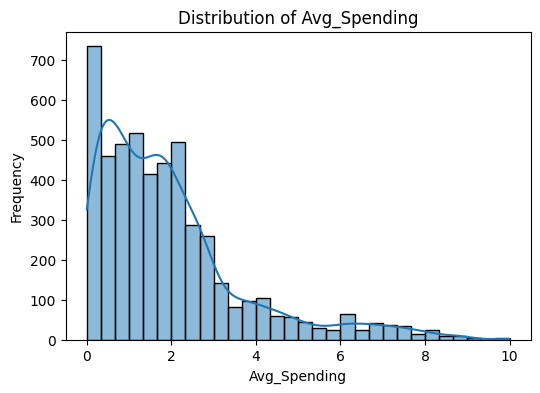

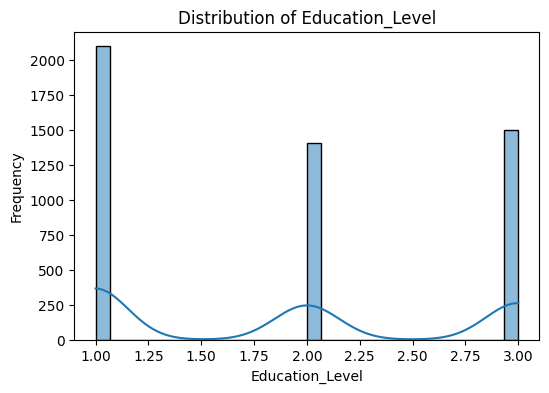

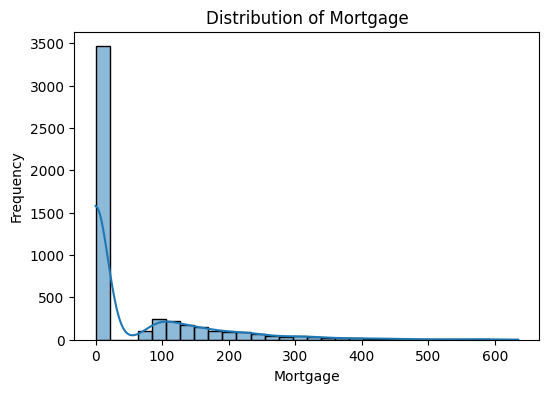

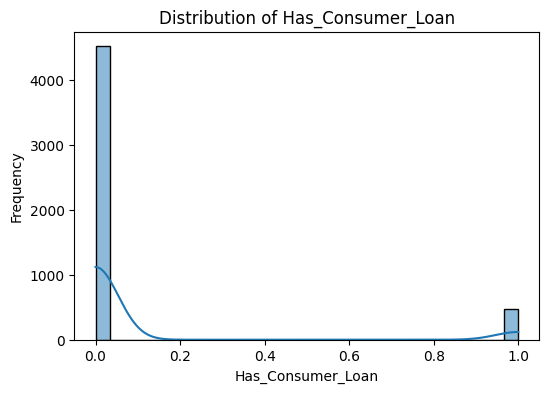

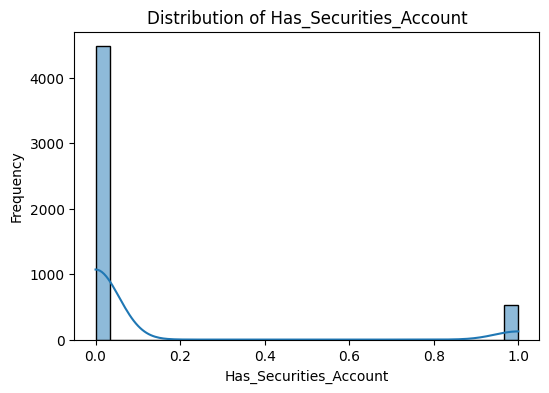

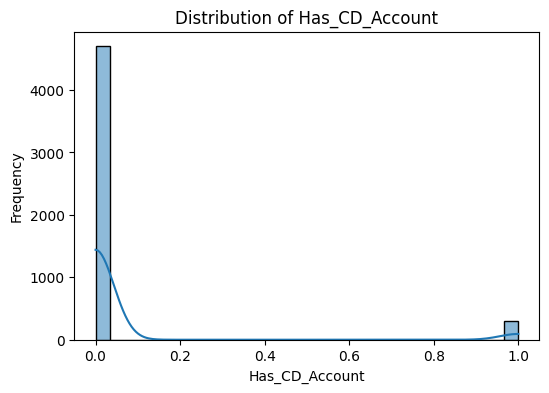

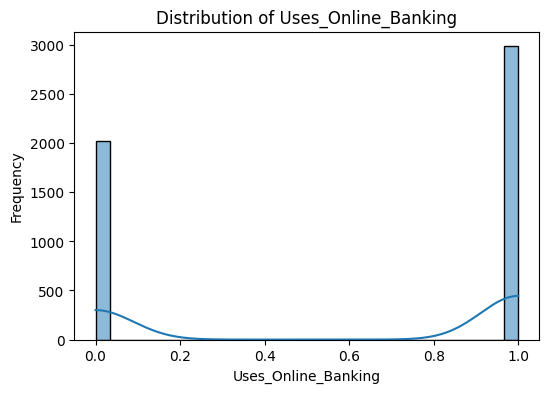

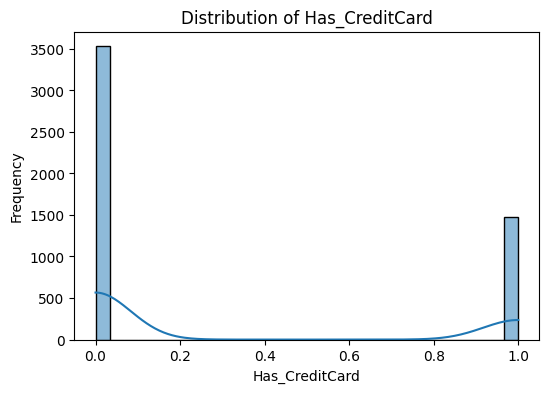

In [42]:
for col in cols_numeric:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True, bins = 30)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

In [43]:
for col in cols_numeric:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df[col] = np.where(df[col] > upper_bound, upper_bound,
  np.where(df[col] < lower_bound, lower_bound, df[col]))

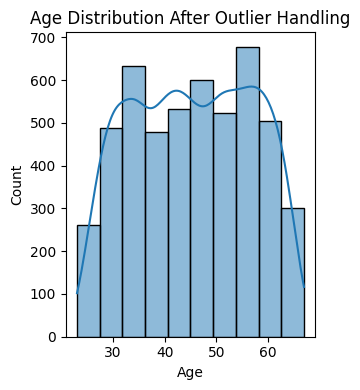

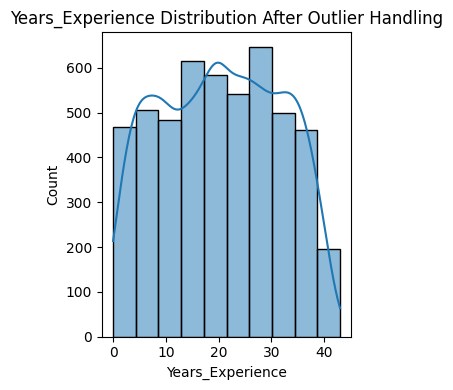

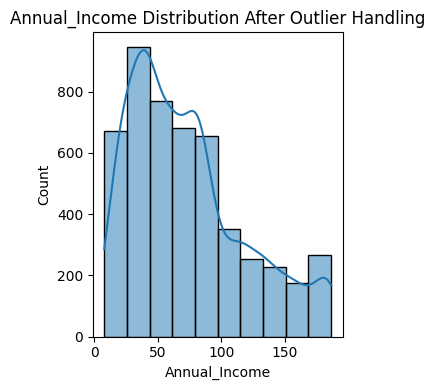

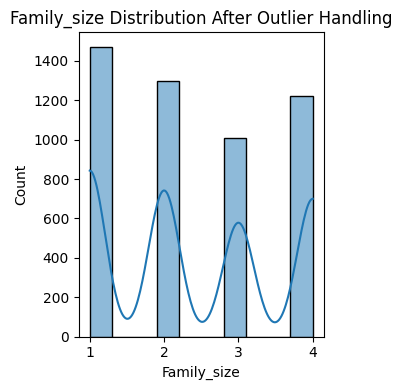

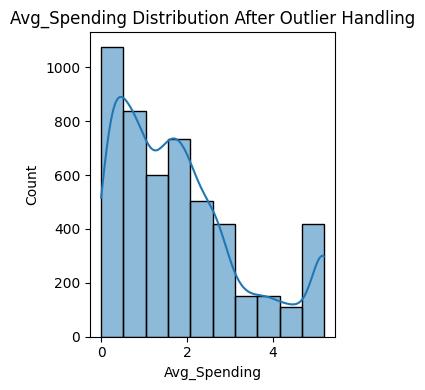

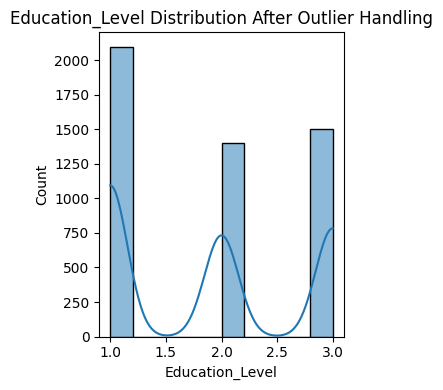

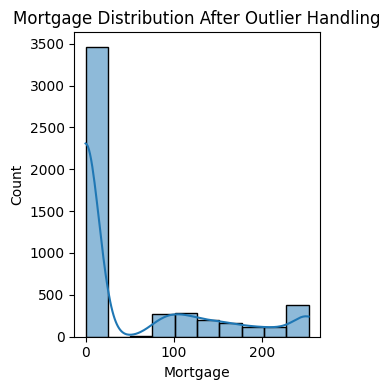

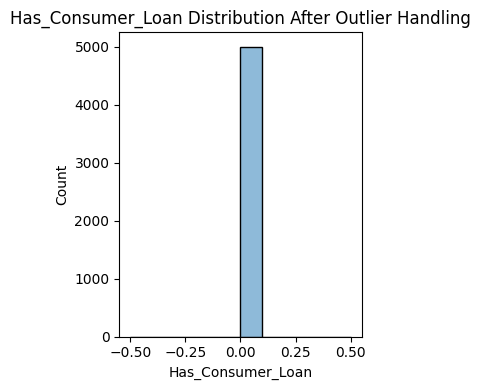

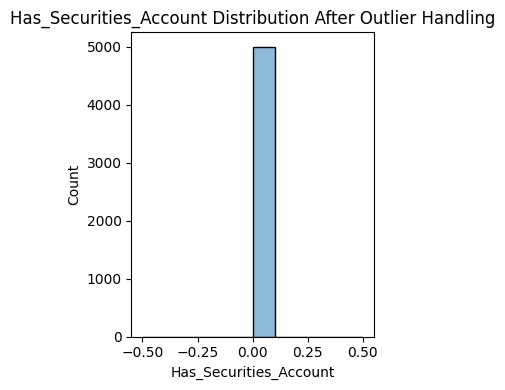

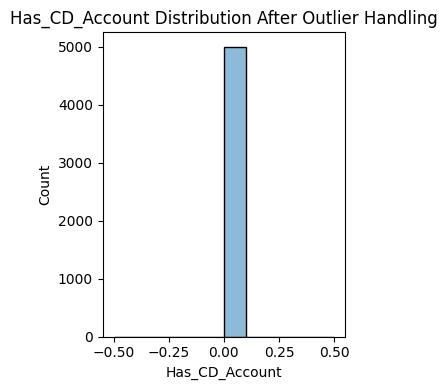

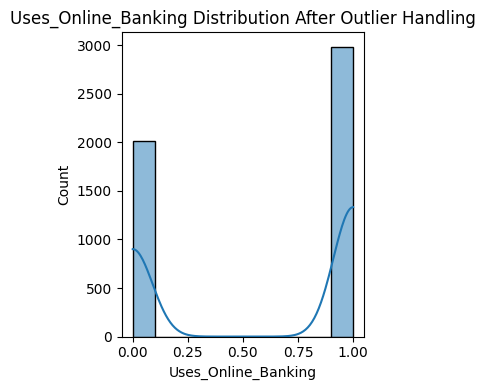

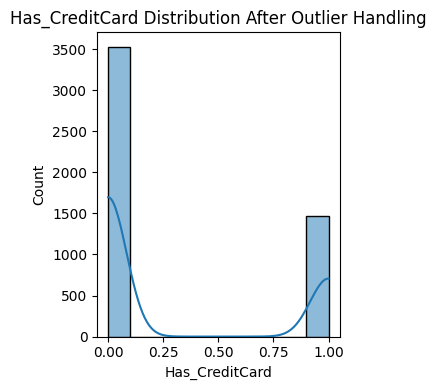

In [44]:
for col in cols_numeric:
  plt.figure(figsize=(6,4))
  plt.subplot(1,2,1)
  sns.histplot(df[col], bins=10, kde=True)
  plt.title(f"{col} Distribution After Outlier Handling")
  plt.tight_layout()
  plt.show()

### Feature Engineer

In [45]:
df['Total_Banking_Products'] = (df['Has_Securities_Account'] +
                                df['Has_CD_Account'] +
                                df['Has_CreditCard'] +
                                df['Uses_Online_Banking'])

df['Income_per_Person'] = df['Annual_Income'] / df['Family_size']

df['Spending_Income_Ratio'] = (df['Avg_Spending'] * 12) / df['Annual_Income']

df['Has_Mortgage_Flag'] = (df['Mortgage'] > 0).astype(int)

In [46]:
df.columns

Index(['Age', 'Years_Experience', 'Annual_Income', 'Family_size',
       'Avg_Spending', 'Education_Level', 'Mortgage', 'Has_Consumer_Loan',
       'Has_Securities_Account', 'Has_CD_Account', 'Uses_Online_Banking',
       'Has_CreditCard', 'Total_Banking_Products', 'Income_per_Person',
       'Spending_Income_Ratio', 'Has_Mortgage_Flag'],
      dtype='object')

### Feature Scaling

In [47]:
selected_features_binary = [
    'Has_Consumer_Loan',
    'Has_Securities_Account',
    'Has_CD_Account',
    'Uses_Online_Banking',
    'Has_CreditCard',
    'Spending_Income_Ratio',
    'Total_Banking_Products'
]
X = df[selected_features_binary].copy()

In [48]:
pca = PCA(n_components=None)
pca.fit(X)
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.where(cumulative_variance_ratio >= 0.9)[0][0] + 1
print(f"PCA components for 90% variance (Binary Features): {n_components_90}")

pca_opt = PCA(n_components=n_components_90)
X_pca = pca_opt.fit_transform(X)

PCA components for 90% variance (Binary Features): 2


In [49]:
scaler_Standard = StandardScaler()
selected_features_binary = scaler_Standard.fit_transform(X)


In [50]:
best_k_pca = None
best_score_pca = -1

scores = []

for k in range(2, 16):
    kmeans_pca = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_pca = kmeans_pca.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels_pca)

    scores.append((k, score))

    print(f"k = {k}, silhouette score = {score:.4f}")

    if score > best_score_pca:
        best_score_pca = score
        best_k_pca = k

print("\n Best Result:")
print(f"Best k = {best_k_pca}")
print(f"Best silhouette score = {best_score_pca:.4f}")


k = 2, silhouette score = 0.6512
k = 3, silhouette score = 0.8575
k = 4, silhouette score = 0.9986
k = 5, silhouette score = 0.8165
k = 6, silhouette score = 0.6865
k = 7, silhouette score = 0.6117
k = 8, silhouette score = 0.6121
k = 9, silhouette score = 0.6101
k = 10, silhouette score = 0.5594
k = 11, silhouette score = 0.5617
k = 12, silhouette score = 0.5482
k = 13, silhouette score = 0.5435
k = 14, silhouette score = 0.5408
k = 15, silhouette score = 0.5516

 Best Result:
Best k = 4
Best silhouette score = 0.9986


In [51]:
final_kmeans = KMeans(
    n_clusters=best_k_pca,
    random_state=42,
    n_init=10
)

final_labels_pca = final_kmeans.fit_predict(X_pca)


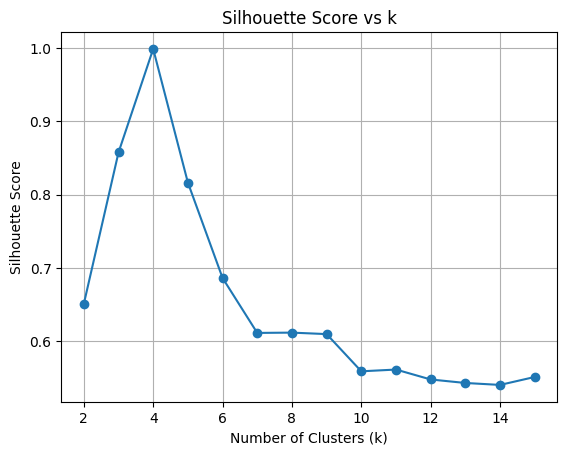

In [52]:
import matplotlib.pyplot as plt

k_values = [score[0] for score in scores]
silhouette_values = [score[1] for score in scores]

plt.plot(k_values, silhouette_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.grid(True)
plt.show()

In [53]:
scaler_Robust = RobustScaler()
X_scaled_robust = scaler_Robust.fit_transform(X)

In [54]:
best_eps = None
best_min_samples = None
best_score_dbscan_opt = -1

for eps in np.arange(0.5, 2.1, 0.1):
    for min_samples in range(5, 16):
        dbscan_opt = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels_dbscan_opt = dbscan_opt.fit_predict(X_scaled_robust)

        unique_labels = np.unique(labels_dbscan_opt)
        n_clusters = len(unique_labels[unique_labels != -1])

        if n_clusters >= 2:
            score = silhouette_score(X_scaled_robust, labels_dbscan_opt)

            print(
                f"eps={eps:.1f}, min_samples={min_samples}, "
                f"clusters={n_clusters}, score={score:.4f}"
            )

            if score > best_score_dbscan_opt:
                best_score_dbscan_opt = score
                best_eps = eps
                best_min_samples = min_samples

print("\nBest DBSCAN Configuration:")
print(f"Best eps = {best_eps}")
print(f"Best min_samples = {best_min_samples}")
print(f"Best Silhouette Score = {best_score_dbscan_opt:.4f}")

eps=0.5, min_samples=5, clusters=4, score=0.5358
eps=0.5, min_samples=6, clusters=4, score=0.5357
eps=0.5, min_samples=7, clusters=4, score=0.5357
eps=0.5, min_samples=8, clusters=4, score=0.5355
eps=0.5, min_samples=9, clusters=4, score=0.5355
eps=0.5, min_samples=10, clusters=4, score=0.5355
eps=0.5, min_samples=11, clusters=4, score=0.5355
eps=0.5, min_samples=12, clusters=4, score=0.5356
eps=0.5, min_samples=13, clusters=4, score=0.5356
eps=0.5, min_samples=14, clusters=4, score=0.5348
eps=0.5, min_samples=15, clusters=4, score=0.5348
eps=0.6, min_samples=5, clusters=4, score=0.5359
eps=0.6, min_samples=6, clusters=4, score=0.5359
eps=0.6, min_samples=7, clusters=4, score=0.5358
eps=0.6, min_samples=8, clusters=4, score=0.5358
eps=0.6, min_samples=9, clusters=4, score=0.5358
eps=0.6, min_samples=10, clusters=4, score=0.5358
eps=0.6, min_samples=11, clusters=4, score=0.5358
eps=0.6, min_samples=12, clusters=4, score=0.5355
eps=0.6, min_samples=13, clusters=4, score=0.5355
eps=0.6, m

In [55]:
final_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

final_labels_dbscan = final_dbscan.fit_predict(X_scaled_robust)


### EVALAUTION

In [56]:
final_score = silhouette_score(X_pca, final_labels_pca)
print(f"Final Silhouette Score (k={best_k_pca}): {final_score:.4f}")

dbi_score = davies_bouldin_score(X_pca, final_labels_pca)
print(f"Davies-Bouldin Index (k={best_k_pca}): {dbi_score:.2f}")


Final Silhouette Score (k=4): 0.9986
Davies-Bouldin Index (k=4): 0.00


In [57]:
unique_labels = np.unique(final_labels_dbscan)
n_clusters = len(unique_labels[unique_labels != -1])

if n_clusters >= 2:
    dbi_dbscan = davies_bouldin_score(
        X_scaled_robust[final_labels_dbscan != -1],
        final_labels_dbscan[final_labels_dbscan != -1]
    )
    print(f"Davies-Bouldin Index (DBSCAN): {dbi_dbscan:.4f}")
else:
    dbi_dbscan = None
    print("Davies-Bouldin cannot be computed (less than 2 clusters)")

Davies-Bouldin Index (DBSCAN): 0.8097


In [58]:
from sklearn.metrics import silhouette_score
import numpy as np

mask = final_labels_dbscan != -1

n_clusters = len(np.unique(final_labels_dbscan[mask]))

if n_clusters >= 2:
    sil_dbscan = silhouette_score(
        X_scaled_robust[mask],
        final_labels_dbscan[mask]
    )
    print(f"Silhouette Score (DBSCAN): {sil_dbscan:.4f}")
else:
    sil_dbscan = None
    print("Silhouette Score cannot be computed (less than 2 clusters)")


Silhouette Score (DBSCAN): 0.5371


In [59]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# KMeans
sil_kmeans = silhouette_score(X_pca, final_labels_pca)
dbi_kmeans = davies_bouldin_score(X_pca, final_labels_pca)

# DBSCAN (من غير noise)
mask = final_labels_dbscan != -1
sil_dbscan = silhouette_score(X_scaled_robust[mask], final_labels_dbscan[mask])
dbi_dbscan = davies_bouldin_score(X_scaled_robust[mask], final_labels_dbscan[mask])

print("KMeans:")
print(f"Silhouette = {sil_kmeans:.4f}")
print(f"Davies-Bouldin = {dbi_kmeans:.4f}\n")

print("DBSCAN:")
print(f"Silhouette = {sil_dbscan:.4f}")
print(f"Davies-Bouldin = {dbi_dbscan:.4f}")


KMeans:
Silhouette = 0.9986
Davies-Bouldin = 0.0020

DBSCAN:
Silhouette = 0.5371
Davies-Bouldin = 0.8097


In [60]:
import joblib
joblib.dump(final_kmeans,"kmeans_model.pkl")
joblib.dump(scaler_Standard,"scaler_Standard.pkl")

joblib.dump(final_dbscan,"dbscan_model.pkl")
joblib.dump(scaler_Robust,"scaler_Robust.pkl")


['scaler_Robust.pkl']